# Experiment 3 - Wavelet + Sharpening

**Pipeline preprocessing:** Haar wavelet denoising untuk mengurangi noise frekuensi tinggi, lalu unsharp mask untuk menajamkan tekstur awan.

## Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Berjalan di Google Colab. Menyiapkan environment...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    REPO_DIR = '/content/cloud-classification'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/Vuxyn/cloud-classification.git
    else:
        !git -C {REPO_DIR} pull
        
    %cd {REPO_DIR}/notebooks
    
    ZIP_PATH = '/content/drive/MyDrive/GCD-zip.zip'
    EXTRACT_DIR = '/content/GCD-zip'
    
    if os.path.exists(ZIP_PATH):
        if not os.path.exists(EXTRACT_DIR):
            print(f"Mengekstrak {ZIP_PATH} ke {EXTRACT_DIR}...")
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print("Ekstraksi selesai!")
        else:
            print(f"Dataset sudah diekstrak di {EXTRACT_DIR}")
    else:
        print(f"Peringatan: File zip {ZIP_PATH} tidak ditemukan di Google Drive Anda.")
        print("Pastikan nama file zip di Drive utama adalah 'GCD-zip.zip'.")

    # Cek apakah runtime menggunakan GPU
    import subprocess
    try:
        subprocess.check_output('nvidia-smi')
        print("GPU NVIDIA terdeteksi, menginstall cupy...")
        !pip install cupy-cuda12x python-dotenv gdown
    except Exception:
        print("GPU tidak aktif. Menjalankan menggunakan CPU.")
        !pip install python-dotenv gdown

In [2]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from src.loader import get_dataset_root, load_dataset
from src.image_processing import *


EXPERIMENT_NAME = "experiment3"


CuPy tidak tersedia - fallback ke NumPy (CPU)


## Data Loading

In [3]:
DATASET_ROOT = get_dataset_root()
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(256, 256))
print(f"Dataset loaded: {len(images)} gambar, {len(set(labels))} kelas")


Environment: Lokal
DATASET_ROOT dari .env: D:\INFORMATICS\SEMESTER 4\IMAGE PROCESSING\Praktikum\Project\GCD


Loading cumulus:   0%|          | 0/775 [00:00<?, ?it/s]

Loading cumulus:   6%|▌         | 46/775 [00:00<00:01, 455.71it/s]

Loading cumulus:  13%|█▎        | 103/775 [00:00<00:01, 518.27it/s]

Loading cumulus:  21%|██        | 159/775 [00:00<00:01, 536.30it/s]

...

Loading mixed:  72%|███████▏  | 438/607 [00:00<00:00, 508.76it/s]

Loading mixed:  81%|████████  | 489/607 [00:00<00:00, 506.34it/s]

Loading mixed:  89%|████████▉ | 540/607 [00:01<00:00, 502.55it/s]

Loading mixed:  97%|█████████▋| 591/607 [00:01<00:00, 498.91it/s]

Dataset loaded: 19000 gambar, 7 kelas, ukuran=(256, 256)
Dataset loaded: 19000 gambar, 7 kelas


## Dataset Visualization & Distribution

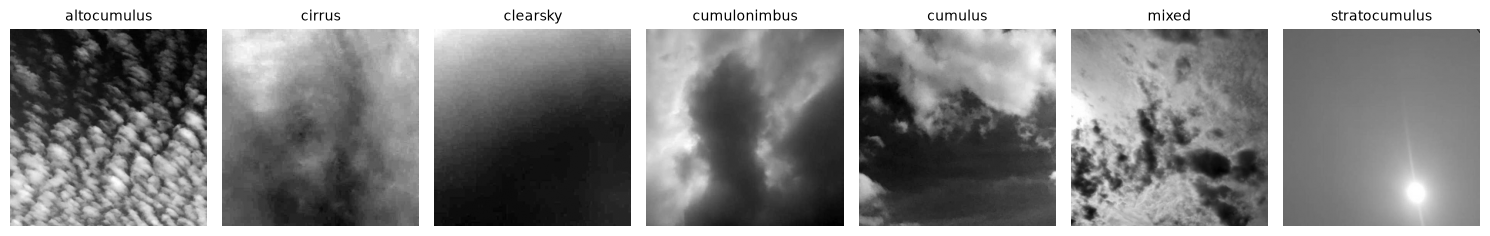

C:\Users\Mahesa\AppData\Local\Temp\ipykernel_43588\492372970.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')


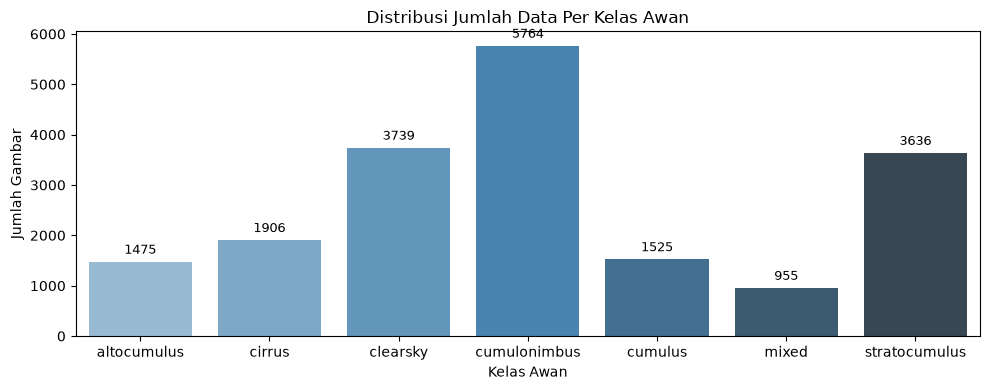

In [4]:
# Tampilkan contoh gambar untuk setiap kelas
unique_labels = sorted(list(set(labels)))
fig, axes = plt.subplots(1, len(unique_labels), figsize=(15, 3))
for i, label in enumerate(unique_labels):
    idx = np.where(labels == label)[0][0]
    img = images[idx]
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
    else:
        axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label, fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Tampilkan bar chart distribusi kelas
plt.figure(figsize=(10, 4))
label_counts = pd.Series(labels).value_counts().sort_index()
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')
plt.title('Distribusi Jumlah Data Per Kelas Awan')
plt.xlabel('Kelas Awan')
plt.ylabel('Jumlah Gambar')
for i, count in enumerate(label_counts.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Preprocessing Pipeline

In [5]:
# ================================================================
# EDIT BAGIAN INI untuk mengubah pipeline preprocessing
# Tambah, hapus, atau ganti fungsi sesuai experiment
# ================================================================

PIPELINE = [
    lambda img: haar_wavelet_denoise(img, level=1, threshold=15.0),
    lambda img: unsharp_mask(img, kernel_size=5, sigma=1.0, amount=1.2),
]

# ================================================================
# Jangan edit di bawah ini
# ================================================================

def apply_pipeline(image: np.ndarray, pipeline: list) -> np.ndarray:
    for fn in pipeline:
        image = fn(image)
    return image


In [6]:
# Terapkan pipeline ke seluruh dataset
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def process_one(img):
    return apply_pipeline(img, PIPELINE)

if not PIPELINE:
    images_preprocessed = images.copy()
else:
    if USING_GPU:
        print("Menggunakan ThreadPoolExecutor (GPU aktif)...")
        with ThreadPoolExecutor(max_workers=4) as executor:
            images_preprocessed = list(tqdm(
                executor.map(process_one, images),
                total=len(images),
                desc="Preprocessing"
            ))
    else:
        print("Menggunakan Pemrosesan Sekuensial CPU (mencegah OOM Crash)...")
        images_preprocessed = [process_one(img) for img in tqdm(images, desc="Preprocessing")]
        
    images_preprocessed = np.array(images_preprocessed)


Menggunakan Pemrosesan Sekuensial CPU (mencegah OOM Crash)...


Preprocessing:   0%|          | 0/19000 [00:00<?, ?it/s]

Preprocessing:   0%|          | 28/19000 [00:00<01:09, 272.75it/s]

Preprocessing:   0%|          | 58/19000 [00:00<01:06, 286.54it/s]

Preprocessing:   0%|          | 88/19000 [00:00<01:05, 290.00it/s]

...

Preprocessing: 100%|█████████▉| 18908/19000 [01:05<00:00, 274.88it/s]

Preprocessing: 100%|█████████▉| 18936/19000 [01:05<00:00, 273.46it/s]

Preprocessing: 100%|█████████▉| 18965/19000 [01:05<00:00, 277.58it/s]

Preprocessing: 100%|█████████▉| 18993/19000 [01:05<00:00, 276.05it/s]

Preprocessing: 100%|██████████| 19000/19000 [01:05<00:00, 290.49it/s]

## Visualisasi Preprocessing

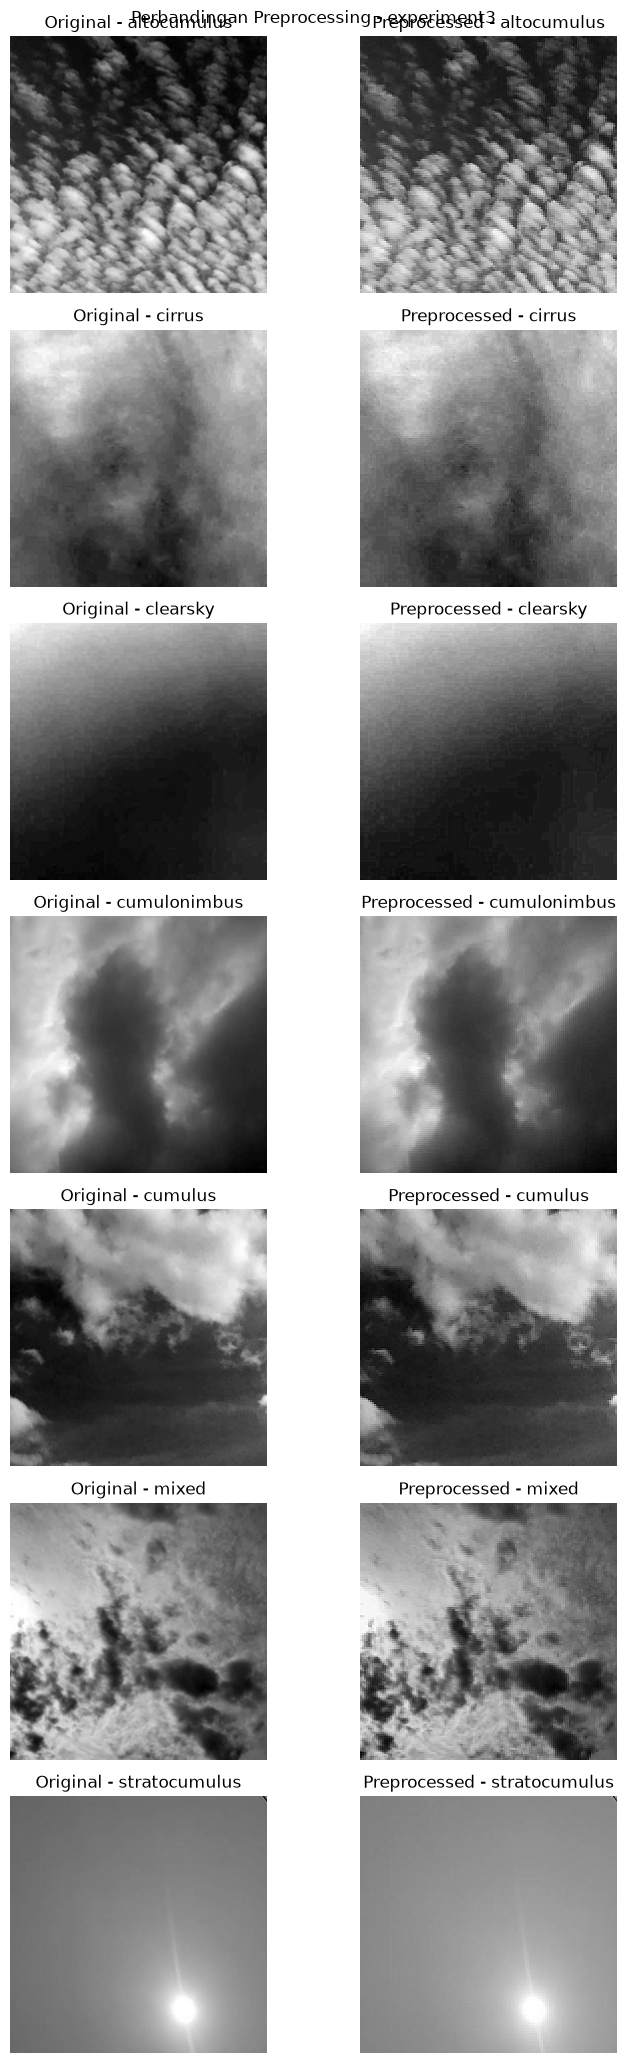

In [7]:
# Tampilkan perbandingan original vs hasil preprocessing
# 1 sample per kelas, 2 kolom: original | preprocessed

unique_labels = sorted(set(labels))
n_classes = len(unique_labels)
fig, axes = plt.subplots(n_classes, 2, figsize=(8, 3 * n_classes))
if n_classes == 1:
    axes = np.array([axes])

for row, label in enumerate(unique_labels):
    idx = next(i for i, lb in enumerate(labels) if lb == label)
    axes[row, 0].imshow(images[idx], cmap='gray')
    axes[row, 0].set_title(f'Original - {label}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(images_preprocessed[idx], cmap='gray')
    axes[row, 1].set_title(f'Preprocessed - {label}')
    axes[row, 1].axis('off')

plt.suptitle(f'Perbandingan Preprocessing - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()


## Feature Extraction (GLCM)

In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan 0, 45, 90, atau 135.")

    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)


def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]


def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]


def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]


def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]


def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]


def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]


def entropyGlcm(matriks):
    return entropy(matriks.ravel())


In [9]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in tqdm(range(len(images_preprocessed)), desc="Extracting GLCM features"):
    # Hitung matriks GLCM
    g0 = glcm(images_preprocessed[i], 0)
    g45 = glcm(images_preprocessed[i], 45)
    g90 = glcm(images_preprocessed[i], 90)
    g135 = glcm(images_preprocessed[i], 135)
    
    # Ekstrak properti on-the-fly untuk menghemat RAM (mencegah crash di Colab)
    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))
    
    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))
    
    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))
    
    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))
    
    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))
    
    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))
    
    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))

dataTable = {
    'Filename': filenames,
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur tersimpan ke {csv_path}')
df.head()


Extracting GLCM features:   0%|          | 0/19000 [00:00<?, ?it/s]

Extracting GLCM features:   0%|          | 6/19000 [00:00<05:19, 59.42it/s]

Extracting GLCM features:   0%|          | 13/19000 [00:00<05:14, 60.32it/s]

Extracting GLCM features:   0%|          | 20/19000 [00:00<05:21, 59.02it/s]

Extracting GLCM features:   0%|          | 27/19000 [00:00<05:17, 59.74it/s]

...

Extracting GLCM features: 100%|█████████▉| 18988/19000 [04:51<00:00, 59.25it/s]

Extracting GLCM features: 100%|█████████▉| 18995/19000 [04:51<00:00, 61.19it/s]

Extracting GLCM features: 100%|██████████| 19000/19000 [04:51<00:00, 65.22it/s]

Fitur tersimpan ke hasil_ekstraksi_experiment3.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1_cumulus_000001.jpg,cumulus,15.281924,30.153126,18.976716,32.372626,0.545988,0.404948,0.503791,0.396582,...,0.002956,0.002048,0.061024,0.045193,0.054369,0.045255,0.990304,0.980870,0.987961,0.979462
1,1_cumulus_000002.jpg,cumulus,12.406235,29.787866,20.029596,31.419531,0.572390,0.415030,0.521459,0.417604,...,0.003596,0.002358,0.062907,0.048061,0.059967,0.048559,0.996490,0.991581,0.994334,0.991120
2,1_cumulus_000003.jpg,cumulus,38.612837,77.377209,43.004320,75.852211,0.459132,0.345800,0.454500,0.340203,...,0.003112,0.001910,0.055797,0.044347,0.055783,0.043704,0.989784,0.979482,0.988593,0.979886
3,1_cumulus_000004.jpg,cumulus,24.674433,49.677724,28.471814,49.918231,0.539814,0.404481,0.505680,0.396019,...,0.003386,0.002068,0.059869,0.047181,0.058188,0.045477,0.993814,0.987535,0.992857,0.987474
4,1_cumulus_000005.jpg,cumulus,14.943428,43.210288,30.952160,43.796386,0.564616,0.351498,0.425340,0.356359,...,0.001495,0.001131,0.049934,0.033179,0.038668,0.033628,0.995864,0.988037,0.991438,0.987874


## Feature Selection

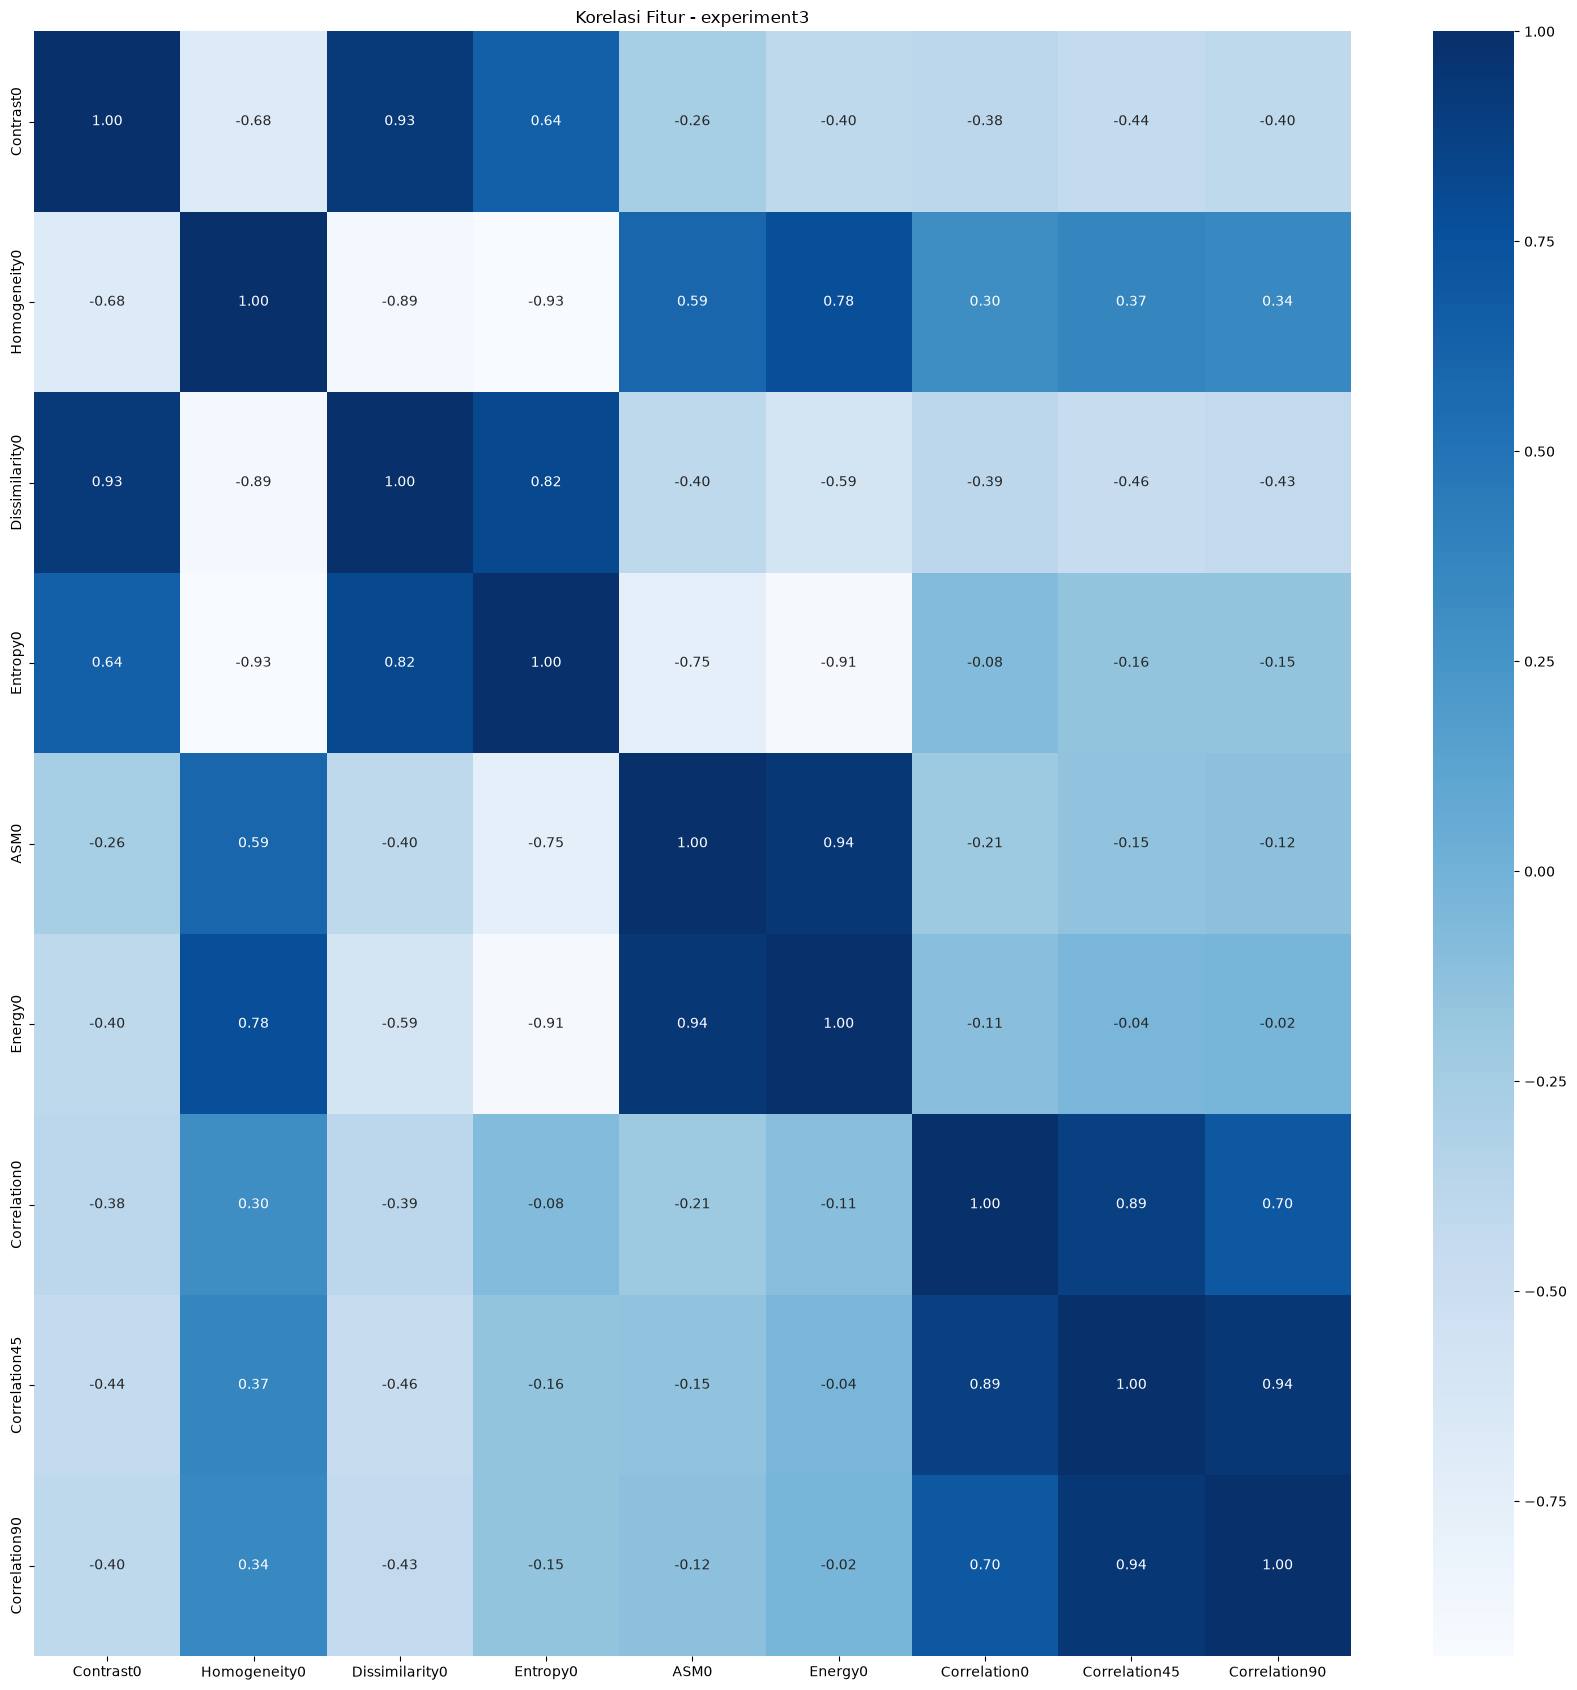

,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Correlation45,Correlation90
0,15.281924,0.545988,2.002114,6.676208,0.003724,0.061024,0.990304,0.980870,0.987961
1,12.406235,0.572390,1.780407,6.711898,0.003957,0.062907,0.996490,0.991581,0.994334
2,38.612837,0.459132,3.200031,7.227215,0.003113,0.055797,0.989784,0.979482,0.988593
3,24.674433,0.539814,2.379887,6.910590,0.003584,0.059869,0.993814,0.987535,0.992857
4,14.943428,0.564616,1.922227,6.967017,0.002493,0.049934,0.995864,0.988037,0.991438
...,...,...,...,...,...,...,...,...,...
18995,12.947733,0.582537,1.755852,6.532668,0.003291,0.057363,0.989235,0.977218,0.986461
18996,20.360325,0.435080,2.584835,7.224997,0.001342,0.036627,0.988349,0.980504,0.989484
18997,13.499004,0.495156,2.072166,7.220089,0.001469,0.038327,0.995382,0.984568,0.988068
18998,23.906434,0.470609,2.507169,7.294927,0.001539,0.039231,0.991908,0.967291,0.972103


In [10]:
# Heatmap korelasi -> drop fitur redundan (threshold 0.95)
correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
selection_feature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label', 'Filename']).columns[columns]
x_new = df[select]
y = df['Label']

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Korelasi Fitur - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

x_new


## Splitting Data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)


(15200, 9)
(3800, 9)


## Feature Normalization

In [12]:
# Z-score normalization - PENTING: fit pada train, apply ke test
mean_train = X_train.mean()
std_train = X_train.std()
X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train


## Modeling

In [13]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)


In [14]:
# Train + evaluate RF
print('------Random Forest - Training Set------')
rf.fit(X_train_norm, y_train)
y_pred_rf_train = rf.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_rf_train)

print('\n------Random Forest - Testing Set------')
y_pred_rf_test = rf.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_rf_test)

# Train + evaluate SVM
print('\n------SVM - Training Set------')
svm.fit(X_train_norm, y_train)
y_pred_svm_train = svm.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_svm_train)

print('\n------SVM - Testing Set------')
y_pred_svm_test = svm.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_svm_test)

# Train + evaluate KNN
print('\n------KNN - Training Set------')
knn.fit(X_train_norm, y_train)
y_pred_knn_train = knn.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_knn_train)

print('\n------KNN - Testing Set------')
y_pred_knn_test = knn.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_knn_test)


------Random Forest - Training Set------


               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00      1180
       cirrus       1.00      1.00      1.00      1525
     clearsky       1.00      1.00      1.00      2991
 cumulonimbus       1.00      1.00      1.00      4611
      cumulus       1.00      1.00      1.00      1220
        mixed       1.00      1.00      1.00       764
stratocumulus       1.00      1.00      1.00      2909

     accuracy                           1.00     15200
    macro avg       1.00      1.00      1.00     15200
 weighted avg       1.00      1.00      1.00     15200

[[1180    0    0    0    0    0    0]
 [   0 1525    0    0    0    0    0]
 [   0    0 2991    0    0    0    0]
 [   0    0    0 4611    0    0    0]
 [   0    0    0    0 1220    0    0]
 [   0    0    0    0    0  764    0]
 [   0    0    0    0    0    0 2909]]
Accuracy: 1.0

------Random Forest - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.69      0.62      0.65       295
       cirrus       0.36      0.24      0.29       381
     clearsky       0.59      0.66      0.62       748
 cumulonimbus       0.57      0.70      0.63      1153
      cumulus       0.73      0.73      0.73       305
        mixed       0.52      0.33      0.40       191
stratocumulus       0.45      0.38      0.41       727

     accuracy                           0.56      3800
    macro avg       0.56      0.52      0.53      3800
 weighted avg       0.55      0.56      0.55      3800

[[182  21   0  60  17   9   6]
 [ 34  91  29 142  21  19  45]
 [  0  13 490  98   2   0 145]
 [ 13  59 105 809  20  11 136]
 [ 11  25   3  21 224  20   1]
 [ 22  27   8  45  21  63   5]
 [  2  20 192 236   1   0 276]]
Accuracy: 0.5618421052631579

------SVM - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.73      0.66      0.69      1180
       cirrus       0.45      0.07      0.12      1525
     clearsky       0.49      0.66      0.56      2991
 cumulonimbus       0.51      0.71      0.59      4611
      cumulus       0.79      0.75      0.77      1220
        mixed       0.54      0.26      0.35       764
stratocumulus       0.43      0.29      0.35      2909

     accuracy                           0.53     15200
    macro avg       0.56      0.48      0.49     15200
 weighted avg       0.53      0.53      0.50     15200

[[ 774   24    5  289   33   48    7]
 [  93  102  136  992   49   22  131]
 [   0    3 1965  502    0    0  521]
 [  30   27  739 3271   58   36  450]
 [  38   43    3  152  920   59    5]
 [ 117   28   16  283  108  196   16]
 [   6    0 1143  909    0    0  851]]
Accuracy: 0.5315131578947369

------SVM - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.71      0.61      0.66       295
       cirrus       0.34      0.06      0.11       381
     clearsky       0.49      0.66      0.56       748
 cumulonimbus       0.51      0.72      0.60      1153
      cumulus       0.77      0.71      0.74       305
        mixed       0.62      0.25      0.36       191
stratocumulus       0.44      0.29      0.35       727

     accuracy                           0.53      3800
    macro avg       0.55      0.47      0.48      3800
 weighted avg       0.52      0.53      0.50      3800

[[181  11   0  77  15   7   4]
 [ 27  24  28 251  16   7  28]
 [  0   1 490 132   1   0 124]
 [ 10   7 187 835  14   3  97]
 [ 11  14   1  46 217  13   3]
 [ 26  13   3  76  18  48   7]
 [  0   0 292 227   0   0 208]]
Accuracy: 0.5271052631578947

------KNN - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.71      0.73      0.72      1180
       cirrus       0.55      0.47      0.51      1525
     clearsky       0.63      0.76      0.69      2991
 cumulonimbus       0.65      0.74      0.69      4611
      cumulus       0.82      0.80      0.81      1220
        mixed       0.68      0.41      0.51       764
stratocumulus       0.62      0.46      0.53      2909

     accuracy                           0.65     15200
    macro avg       0.67      0.62      0.64     15200
 weighted avg       0.65      0.65      0.64     15200

[[ 858   51    7  153   33   60   18]
 [ 104  724  114  422   38   19  104]
 [   7   53 2279  294    0    0  358]
 [  68  237  511 3423   46   24  302]
 [  37   74    4   75  980   45    5]
 [ 107   96   13  132   90  310   16]
 [  24   88  715  753    1    1 1327]]
Accuracy: 0.6513815789473684

------KNN - Testing Set------
               precision    recall  f1-score   support

  altocum

## Evaluation - Confusion Matrix

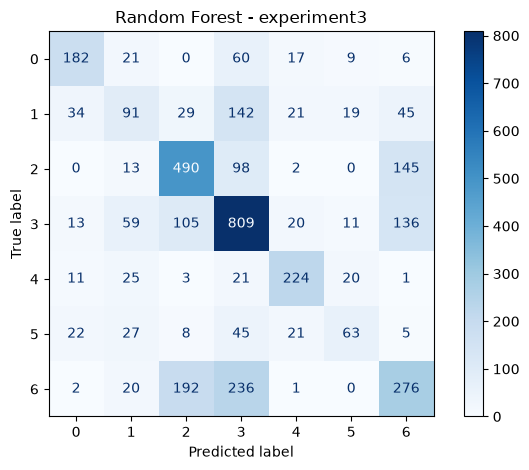

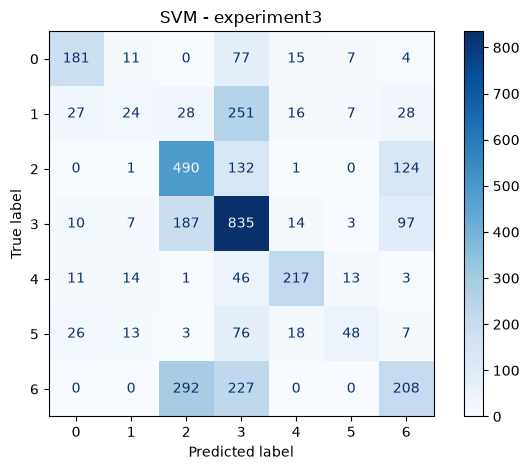

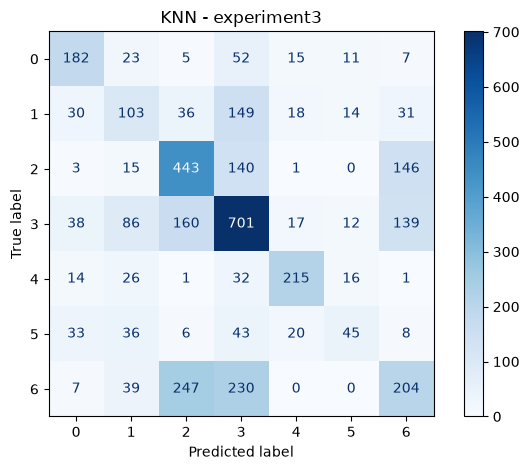

In [15]:
from pathlib import Path

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(
    y_test, y_pred_rf_test,
    f'Random Forest - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_rf.png'
)
plot_confusion_matrix(
    y_test, y_pred_svm_test,
    f'SVM - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_svm.png'
)
plot_confusion_matrix(
    y_test, y_pred_knn_test,
    f'KNN - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_knn.png'
)


In [16]:
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

# Update baris experiment ini saja (hindari duplikat saat re-run)
if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

# Jalankan script untuk meng-update tabel di README.md
import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil di-update dengan tabel metrik terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics


Metrics disimpan ke ..\results\metrics.csv (30 baris total)


README.md berhasil di-update dengan tabel metrik terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,experiment4,rf,0.573158,0.559245,0.573158,0.554307
1,experiment4,svm,0.554737,0.538212,0.554737,0.513967
2,experiment4,knn,0.522895,0.508473,0.522895,0.508296
3,experiment5,rf,0.824211,0.823815,0.824211,0.823726
4,experiment5,svm,0.788158,0.801878,0.788158,0.792259
5,experiment5,knn,0.794474,0.789442,0.794474,0.788857
6,experiment6,rf,0.841316,0.840541,0.841316,0.840641
7,experiment6,svm,0.796316,0.806568,0.796316,0.799717
8,experiment6,knn,0.786053,0.780290,0.786053,0.779974
9,experiment7,rf,0.658947,0.659916,0.658947,0.657517


## Analisis

> **[ISI ANALISIS DI SINI]**
> Jelaskan:
> - Pengaruh pipeline preprocessing terhadap fitur GLCM
> - Perbandingan performa antar classifier
> - Kelas mana yang paling sulit diklasifikasikan dan mengapa